In [3]:
!pip install pandas numpy matplotlib seaborn plotly sqlalchemy

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\SHALINI\Downloads\Ecommerce_Sales_Data_2024_2025.csv")
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [6]:
df.shape

(5000, 14)

In [7]:
df.columns

Index(['Order ID', 'Order Date', 'Customer Name', 'Region', 'City', 'Category',
       'Sub-Category', 'Product Name', 'Quantity', 'Unit Price', 'Discount',
       'Sales', 'Profit', 'Payment Mode'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


In [9]:
df.describe()

,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


In [10]:
df.isnull().sum()

Order ID         0
Order Date       0
Customer Name    0
Region           0
City             0
Category         0
Sub-Category     0
Product Name     0
Quantity         0
Unit Price       0
Discount         0
Sales            0
Profit           0
Payment Mode     0
dtype: int64

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

In [12]:
df.dropna(inplace=True)

In [13]:
df.duplicated().sum()

0

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order ID       5000 non-null   int64         
 1   Order Date     5000 non-null   datetime64[ns]
 2   Customer Name  5000 non-null   object        
 3   Region         5000 non-null   object        
 4   City           5000 non-null   object        
 5   Category       5000 non-null   object        
 6   Sub-Category   5000 non-null   object        
 7   Product Name   5000 non-null   object        
 8   Quantity       5000 non-null   int64         
 9   Unit Price     5000 non-null   int64         
 10  Discount       5000 non-null   int64         
 11  Sales          5000 non-null   float64       
 12  Profit         5000 non-null   float64       
 13  Payment Mode   5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 547.

In [17]:
df['Category'] = df['Category'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Payment Mode'] = df['Payment Mode'].astype('category')

In [18]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

In [19]:
df = df[(df['Sales'] >= lower_limit) & 
        (df['Sales'] <= upper_limit)]

In [20]:
df.to_csv('../data/cleaned_ecommerce_sales.csv', index=False)

In [21]:
plt.figure(figsize=(8,5))

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

C:\Users\SHALINI\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


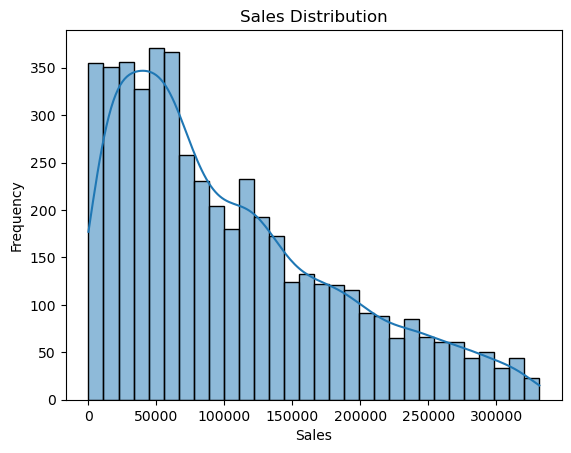

In [22]:
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

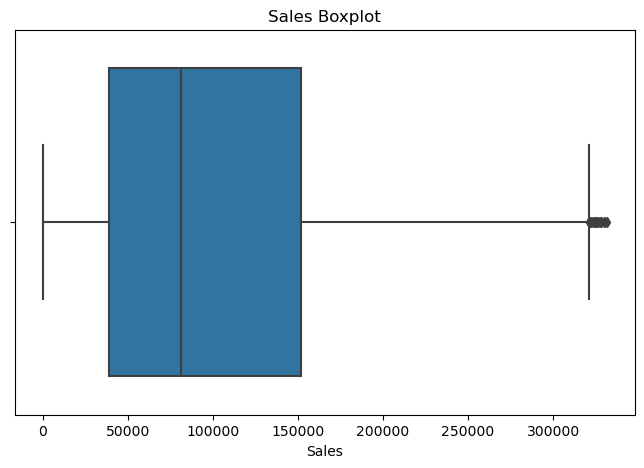

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sales'])
plt.title('Sales Boxplot')
plt.show()

C:\Users\SHALINI\AppData\Local\Temp\ipykernel_21864\2226853790.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = df.groupby('Category')['Sales'].sum()


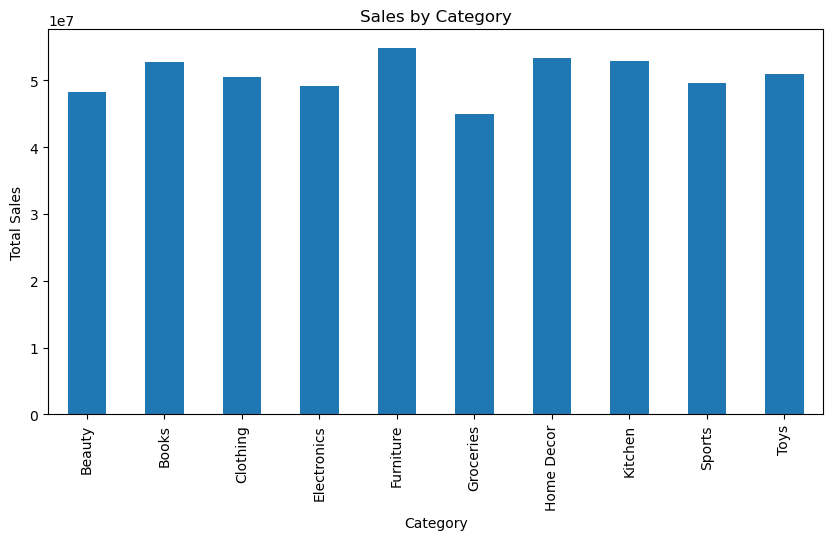

In [24]:
category_sales = df.groupby('Category')['Sales'].sum()
plt.figure(figsize=(10,5))
category_sales.plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

C:\Users\SHALINI\AppData\Local\Temp\ipykernel_21864\1354889822.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  region_profit = df.groupby('Region')['Profit'].sum()


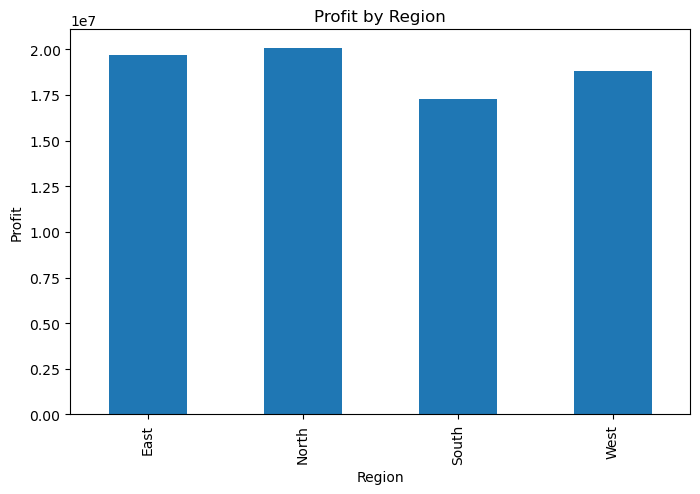

In [25]:
region_profit = df.groupby('Region')['Profit'].sum()
plt.figure(figsize=(8,5))
region_profit.plot(kind='bar')
plt.title('Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit')
plt.show()

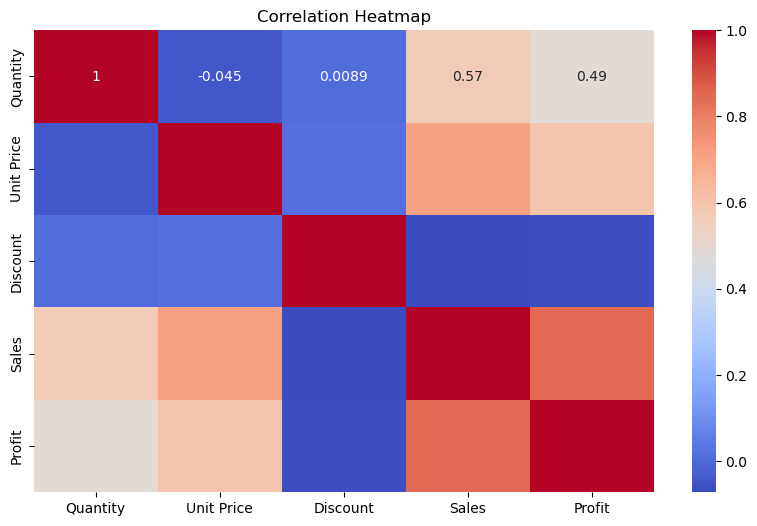

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']].corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [27]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [28]:
monthly_sales = df.groupby('Month')['Sales'].sum()

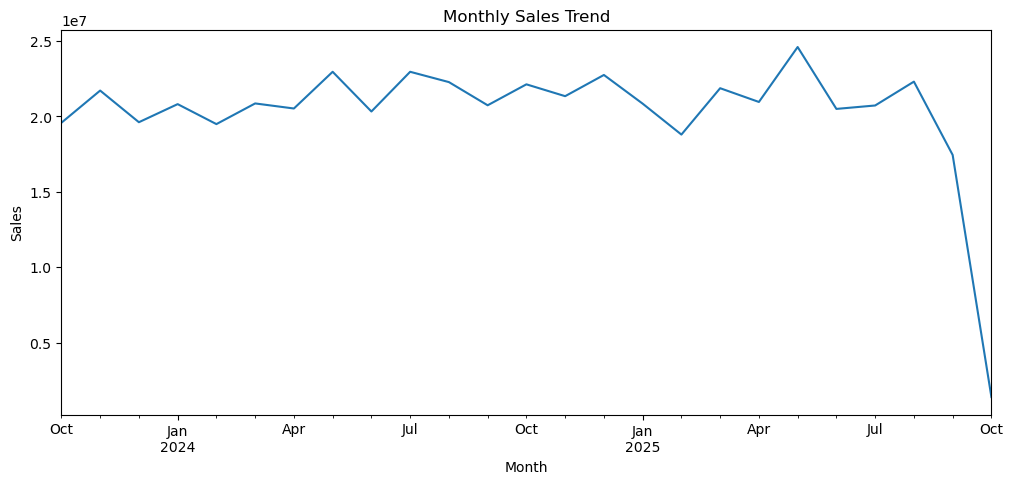

In [29]:
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

## Key Insights

1. **Groceries and Kitchen are frequently purchased categories** — Among the sample of orders, Groceries and Kitchen items appear most often, suggesting these are high-frequency, everyday purchase categories compared to items like Furniture or Home Decor.

2. **Discounts are applied in fixed tiers** — Discount values consistently appear as 0%, 5%, 10%, 15%, or 20%, indicating the business uses standardized discount slabs rather than random or continuous discounting.

3. **Electronics generates high-value transactions** — Despite being ordered less frequently, Electronics items (e.g., Laptops, Smartwatches) show some of the highest Sales and Profit values per order, indicating high price points per unit.

4. **Digital payment methods dominate** — Credit Card, Debit Card, and UPI together account for the majority of payment modes used, with Cash on Delivery (COD) appearing far less often.

5. **Profit margins vary notably by category** — Orders with higher discounts (15-20%) still generated substantial profit in categories like Electronics and Books, suggesting healthy base margins that absorb discounting well.

In [30]:
df.to_csv('../data/cleaned_ecommerce_data.csv', index=False)